In [7]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.dataset import DEAMDataset
from src.model import EmotionCNN
from torch.utils.data import DataLoader, random_split


In [9]:
dataset = DEAMDataset(
    "../data/labels/deam_song_level_labels.csv",
    "../data/processed/mel_spectrograms"
)

print("Dataset size:", len(dataset))


[INFO] Dataset size after filtering: 1802
Dataset size: 1802


In [10]:
import torch
from torch.utils.data import DataLoader, random_split
from src.dataset import DEAMDataset

# Load full dataset
dataset = DEAMDataset(
    "../data/labels/deam_song_level_labels.csv",
    "../data/processed/mel_spectrograms"
)

# Limit to 100 songs
dataset = torch.utils.data.Subset(dataset, range(100))

print("Total samples:", len(dataset))

# Split 70/15/15
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size]
)

# DataLoaders (Batch size = 4)
train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
val_loader = DataLoader(val_set, batch_size=4)
test_loader = DataLoader(test_set, batch_size=4)

print("Train:", len(train_set))
print("Val:", len(val_set))
print("Test:", len(test_set))

[INFO] Dataset size after filtering: 1802
Total samples: 100
Train: 70
Val: 15
Test: 15


In [11]:
import torch.nn as nn
import torch.optim as optim
from src.model import EmotionCNN

device = torch.device("cpu")

model = EmotionCNN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    # -------- Validation --------
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
     for X, y in val_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epoch}] "
      f"Train Loss: {train_loss:.4f} | "
      f"Val Loss: {val_loss:.4f}")
    

Epoch [1/0] Train Loss: 0.2188 | Val Loss: 0.0816
Epoch [2/1] Train Loss: 0.1100 | Val Loss: 0.0870
Epoch [3/2] Train Loss: 0.0934 | Val Loss: 0.0791
Epoch [4/3] Train Loss: 0.0840 | Val Loss: 0.0738
Epoch [5/4] Train Loss: 0.0820 | Val Loss: 0.0841
Epoch [6/5] Train Loss: 0.0892 | Val Loss: 0.0697
Epoch [7/6] Train Loss: 0.0820 | Val Loss: 0.0829
Epoch [8/7] Train Loss: 0.0788 | Val Loss: 0.0646
Epoch [9/8] Train Loss: 0.0784 | Val Loss: 0.0819
Epoch [10/9] Train Loss: 0.0771 | Val Loss: 0.0716
Epoch [11/10] Train Loss: 0.0671 | Val Loss: 0.0814
Epoch [12/11] Train Loss: 0.0780 | Val Loss: 0.0651
Epoch [13/12] Train Loss: 0.0741 | Val Loss: 0.0654
Epoch [14/13] Train Loss: 0.0714 | Val Loss: 0.0805
Epoch [15/14] Train Loss: 0.0674 | Val Loss: 0.0819
Epoch [16/15] Train Loss: 0.0726 | Val Loss: 0.0701
Epoch [17/16] Train Loss: 0.0754 | Val Loss: 0.0725
Epoch [18/17] Train Loss: 0.0654 | Val Loss: 0.0718
Epoch [19/18] Train Loss: 0.0718 | Val Loss: 0.0744
Epoch [20/19] Train Loss: 0.059

In [12]:
import os

base_dir = os.path.abspath("..")  # go to project root
model_path = os.path.join(base_dir, "models", "emotion_cnn_regression.pth")

os.makedirs(os.path.dirname(model_path), exist_ok=True)
torch.save(model.state_dict(), model_path)

print("Model saved at:", model_path)

Model saved at: d:\music-emotion-recognition\models\emotion_cnn_regression.pth


In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)

        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(y.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae = mean_absolute_error(all_targets, all_preds)

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 0.22971284687551397
Test MAE: 0.19489939510822296


In [14]:
import pandas as pd
import os

os.makedirs("../results/metrics", exist_ok=True)

metrics_df = pd.DataFrame({
    "RMSE": [rmse],
    "MAE": [mae]
})

metrics_df.to_csv("../results/metrics/test_metrics.csv", index=False)

print("Metrics saved.")

Metrics saved.


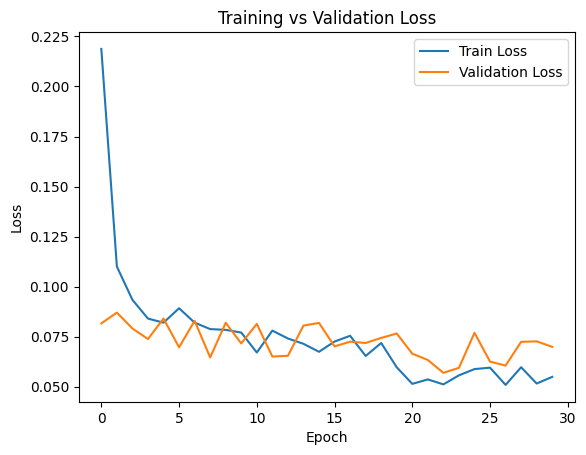

In [15]:
import matplotlib.pyplot as plt
import os

os.makedirs("../results/plots", exist_ok=True)

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("../results/plots/loss_curve.png")
plt.show()

In [16]:
dataset = DEAMDataset(
    "../data/labels/deam_song_level_labels.csv",
    "../data/processed/mel_spectrograms"
)

[INFO] Dataset size after filtering: 1802


In [17]:
mel, target = dataset[0]
print(target)


tensor([-0.4750, -0.5000])


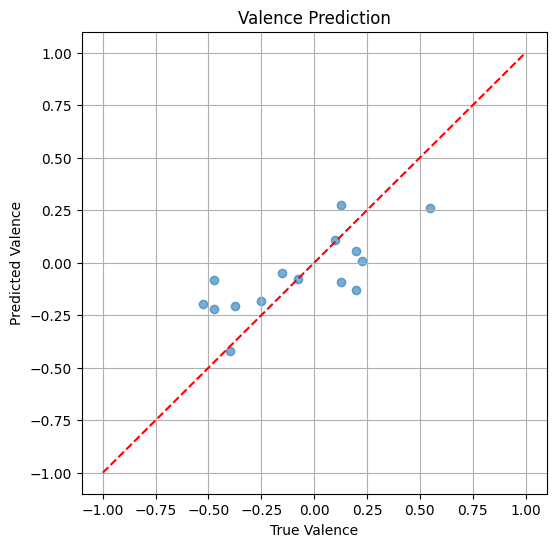

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(all_targets[:,0], all_preds[:,0], alpha=0.6)
plt.plot([-1,1], [-1,1], 'r--')  # perfect prediction line
plt.xlabel("True Valence")
plt.ylabel("Predicted Valence")
plt.title("Valence Prediction")
plt.grid(True)
plt.show()

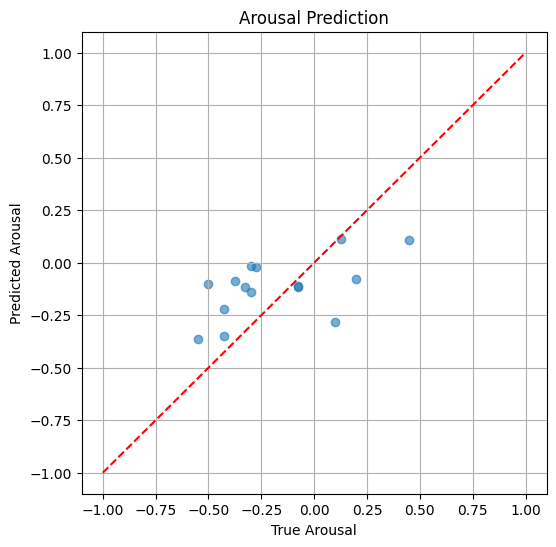

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(all_targets[:,1], all_preds[:,1], alpha=0.6)
plt.plot([-1,1], [-1,1], 'r--')
plt.xlabel("True Arousal")
plt.ylabel("Predicted Arousal")
plt.title("Arousal Prediction")
plt.grid(True)
plt.show()

In [22]:
import os

# Create correct path relative to notebook
os.makedirs("../results/plots", exist_ok=True)

plt.savefig("../results/plots/valence_scatter.png")
plt.savefig("../results/plots/arousal_scatter.png")

<Figure size 640x480 with 0 Axes>